In [1]:
## --- IMPORTS --- ###
import GPKoopman as gpk
import torch
import matplotlib.pyplot as plt
import time
import numpy as np
import math
from datasets import load_dataset
from itertools import combinations_with_replacement
import warnings
warnings.filterwarnings("ignore")
import gc

In [2]:
def generate_monomial_powers(nx: int, total_orders=(2, 3)):
    """
    Return exponent tuples for all unique monomials whose total degree
    is in `total_orders`.

    Example for nx=2:
        degree 2: (2,0), (1,1), (0,2)
        degree 3: (3,0), (2,1), (1,2), (0,3)
    """
    power_list = []

    for order in total_orders:
        for combo in combinations_with_replacement(range(nx), order):
            powers = [0] * nx
            for idx in combo:
                powers[idx] += 1
            power_list.append(tuple(powers))

    return power_list


@torch.no_grad()
def build_G_cache(manager, X, Xplus) -> tuple[torch.Tensor]:
    """
    Build detached G caches for Z-only optimization.

    Returns
    -------
    G_X      : (nz, S, r)
    G_Xplus  : (nz, S, r)

    where:
        nz = number of observables
        S = N*nT
        r = number of virtual targets
    """
    nz = manager.num_obs
    r = manager.observables[0].Ns # Z.shape[0]
    S = X.shape[1]

    G_X_list, G_Xplus_list = [], []

    for i in range(nz):
        obs = manager.observables[i]

        Gi = obs.forward_G(X)       # X : (nx, N*nT) -> Gi : (N*nT, r)
        Gpi = obs.forward_G(Xplus)  # (N*nT, r)

        G_X_list.append(Gi)
        G_Xplus_list.append(Gpi)

    G_X = torch.stack(G_X_list, dim=0).contiguous()
    G_Xplus = torch.stack(G_Xplus_list, dim=0).contiguous()

    return G_X, G_Xplus


In [3]:
def get_cost_simple_fast(
    Z, X, G_X, G_Xplus,
    lambda1=1.0, lambda2=1.0, lambda3=1.0,
    jitter=1e-6,
    Mp_X0=None, Mp_X=None, Mp_Xplus=None,
    num_total_samples: int | None = None,
):
    """
    Fast iGPK projection cost.

    Supports both full-batch and mini-batch evaluation.

    If num_total_samples is not None, the Frobenius norms are scaled by

        sqrt(num_total_samples / batch_samples)

    so that mini-batch costs are approximately on the same scale as the
    full-batch cost.
    """
    nz = Z.shape[1]
    Ns = Z.shape[0]
    dtype = G_X.dtype
    device = G_X.device

    # ------------------------------------------------------------
    # 1. Build lifted mean matrices M and Mplus
    # ------------------------------------------------------------
    if Mp_X0 is not None:
        lifted_residual = Z - Mp_X0
        M = Mp_X + torch.einsum("isr,ri->is", G_X, lifted_residual)
        Mplus = Mp_Xplus + torch.einsum("isr,ri->is", G_Xplus, lifted_residual)
    else:
        M = torch.einsum("isr,ri->is", G_X, Z)
        Mplus = torch.einsum("isr,ri->is", G_Xplus, Z)

    # ------------------------------------------------------------
    # 2. Compute Gram matrix in lifted space
    # ------------------------------------------------------------
    eye_p = torch.eye(nz, dtype=dtype, device=device)
    Gram = M @ M.mT

    try:
        L = torch.linalg.cholesky(Gram + jitter * eye_p)
    except RuntimeError:
        try:
            L = torch.linalg.cholesky(Gram + (10 * jitter) * eye_p)
        except RuntimeError:
            L = torch.linalg.cholesky(Gram + (100 * jitter) * eye_p)

    # ------------------------------------------------------------
    # 3. Compute B P_M without forming P_M
    # ------------------------------------------------------------
    B = torch.cat([Mplus, X], dim=0)  # (nz + nx, S_batch)

    BMt = B @ M.mT
    coeff = torch.cholesky_solve(BMt.mT, L).mT

    residual = B - coeff @ M

    R1 = residual[:nz, :]
    R2 = residual[nz:, :]

    # ------------------------------------------------------------
    # 4. Cost
    # ------------------------------------------------------------
    cost1 = torch.linalg.matrix_norm(R1, ord="fro")
    cost2 = torch.linalg.matrix_norm(R2, ord="fro")

    if num_total_samples is not None:
        batch_samples = X.shape[1]
        scale = (num_total_samples / batch_samples) ** 0.5
        cost1 = scale * cost1
        cost2 = scale * cost2

    return ((lambda1 * cost1) + (lambda2 * cost2)) / (nz * Ns)

In [4]:
def getKoopman(manager: gpk.GPObservablesManager,
               X :torch.Tensor, Xplus : torch.Tensor,
               nT : int, stateAug : bool = False) -> tuple[torch.Tensor]:
    """
    Compute Koopman A matrix using the manager for GPObservables.

    Args:
        manager (GPObservablesManager): Manager holding all GPObservable objects.
        indices (list): List of indices for observables to include.
        Xall (torch.Tensor): n x (N+1) matrix of state trajectory.
        nT (float): number of trajectories in training dataset

    Returns: tuple[torch.Tensor]
        A (torch.Tensor): p x p linear state transition matrix.
        C (torch.Tensor): n x p output matrix.
    """

    if not isinstance(manager, gpk.GPObservablesManager):
        raise ValueError(
            'Expected argument manager to be object of class GPObservablesManager')
    
    if X.shape != Xplus.shape:
        raise ValueError('X and Xplus should be the same shape. '
                         f'Recieved {X.shape} and {Xplus.shape} instead.')

    # n = Xall.shape[0]       # dimensionality of original system
    # N = (Xall.shape[1])//nT - 1  # Number of time steps in each trajectory
    # p = len(indices)        # number of observables
    nx = X.shape[0]
    N = X.shape[1]//nT
    nz = manager.num_obs
    device = manager.observables[0].device
    dtype = manager.observables[0].dtype
    X, Xplus = X.to(device=device, dtype=dtype), Xplus.to(device=device, dtype=dtype)

    M = torch.zeros((nz, N*nT), device=device)
    Mplus = torch.zeros((nz, N*nT), device=device)
    for i in range(nz):
        M[i, :] = torch.transpose(manager.predict_mean(i, X), dim0=0, dim1=-1)
        Mplus[i, :] = torch.transpose(
            manager.predict_mean(i, Xplus), dim0=0, dim1=-1)

    if stateAug:
        M = torch.vstack((X, M))
        Mplus = torch.vstack((Xplus, Mplus))

    # Compute C(z) and A(z)
    try:
        L = torch.linalg.cholesky(M @ M.mT +
                (1e-8) * torch.eye(nz, device=M.device))
        M_pinv = torch.cholesky_solve(M, L).mT
    except RuntimeError:
        M_pinv = torch.linalg.pinv(M)
    
    A = Mplus @ M_pinv

    if stateAug:
        C = torch.stack([torch.eye(nx), 
                         torch.zeros([nx, nz])], dim=1).to(device=M.device)
    else:
        C = X[17:18,:] @ M_pinv

    return A, C

In [5]:
def sim_and_eval(ObsManager, A, C, ICset, SimData_ref, traj_offset: int = 0):
    """
    Simulate from Koopman (A, C) for each IC in ICset and compute per-trajectory NRMSE.
    Returns (Xhat, Xcvhat, NRMSE).

    Args:
        ObsManager: trained GPObservablesManager
        A, C: Koopman matrices (CPU or GPU OK; function will move to CPU to simulate)
        ICset: (n, nTraj) tensor of initial conditions for this split (train or test)
        SimData_ref: normalized (or chosen reference) data, shape (num_traj, n, N+1)
        traj_offset: index offset into SimData_ref for this split
    """
    A, C = A.to(device='cpu'), C.to(device='cpu')
    ICset = ICset.to(device='cpu')
    SimData_ref = SimData_ref.to(device='cpu')

    nTraj = ICset.shape[1]
    n_y = C.shape[0]
    nx = SimData_ref.shape[1]
    N = SimData_ref.shape[2] - 1
    p = A.shape[0]

    Zmean = torch.zeros((nTraj, p, N), dtype=ICset.dtype, device=ICset.device)
    # Zcv = torch.zeros((nTraj, p, p, N), dtype=ICset.dtype, device=ICset.device)
    Xhat = torch.zeros((nTraj, n_y, N), dtype=ICset.dtype, device=ICset.device)
    # Xcv = torch.zeros((nTraj, n_y, n_y, N), dtype=ICset.dtype, device=ICset.device)
    NRMSE = torch.zeros((nTraj, n_y), dtype=ICset.dtype, device=ICset.device)

    for j in range(nTraj):
        # 1) Predict initial lifted state distribution from IC
        for i in range(p):
            Zmean[j, i, 0] = ObsManager.predict_mean(i, ICset[:, j].view(nx, 1))
            # Zcv[j, i, i, 0] = ObsManager.predict_covariance(
            #     i, ICset[:, j].view(nx, 1)).clamp(min=1e-8, max=1e8)
            # if torch.isnan(Zcv[j, i, i, 0]).any():
            #     warnings.warn(f"GPO-{i} produced NaN lifted cov for {j}-th trajectory", RuntimeWarning)
            # if Zcv[j, i, i, 0] > 1e20:
            #     warnings.warn(f"GPO-{i} produced lifted cov > 1e20 for {j}-th trajectory")

        # 2) Propagate with linear model
        Zmean[j], Xhat[j] = gpk.sim_LTI(
            Zmean[j, :, 0].view(p, 1), A, C, num_steps=N, ts=None, x0cv=None
        )
        # if torch.isnan(Zcv).any():
        #     warnings.warn(f"sim_LTI produced NaN lifted covariance for {j}-trajectory", UserWarning)
        # 3) NRMSE against reference (per-trajectory range)
        y_true = SimData_ref[traj_offset + j, 17:18, :N]  # (n_y, N)
        errors = Xhat[j] - y_true
        rmse = torch.sqrt(torch.mean(errors**2, dim=1))                 # (n_y,)
        y_max = y_true.max(dim=1).values
        y_min = y_true.min(dim=1).values
        y_range = torch.where((y_max - y_min) == 0,
                              torch.ones_like(y_max),
                              (y_max - y_min))
        NRMSE[j] = rmse #/ y_range

    return Xhat.detach(), NRMSE.detach()

In [6]:
def get_iGPK(
    Data: torch.tensor,          # (num_traj, n_x, N+1)
    nTrain: int,
    nTest: int,
    lifting_order: int = 10,
    max_iter: int = 100,
    sgd_lr: float = 0.01,
    sgd_m: float = 0.8,
    stop_tol: float = 1e-6,
    opt_weights: list[float] = [1., 1., 0.01],
    routine: str = "standard",        # OR "multi-perturb" - to be implemented
    train_method: str = "Zero-Mean",  # Zero-Mean | Monomials
    hp_scale: list[float] = [None, 1.0, None],  # [hp1, hp2, _]
    device: str | torch.device = "cuda:0",
    seed_z: int = 1234,
    seed_hp: int = 1234,

    # ------------------------------------------------------------
    # New batch-SGD controls
    # ------------------------------------------------------------
    traj_batch_size: int | None = None,
    full_cost_eval_every: int = 50,
):
    """
    Train iGPK using trajectory-wise mini-batch SGD on Z.

    traj_batch_size:
        Number of full trajectories used in each SGD step.
        If None or >= nTrain, this recovers full-batch SGD.

    full_cost_eval_every:
        Frequency at which the full training cost is evaluated for
        checkpointing and early stopping.
    """
    SimData = Data['SimData']
    X = Data['X']
    Xplus = Data['Xplus']
    Xtrain = Data['Xtrain']

    # ------------------------------------------------------------
    # Shapes and basic splits
    # ------------------------------------------------------------
    nx, N, Ns_gpo = Data['dims']
    nz = int(lifting_order)

    t0 = time.perf_counter()

    ObsManager = gpk.GPObservablesManager()

    # ------------------------------------------------------------
    # Initialize manager and decision variable Z
    # ------------------------------------------------------------
    if train_method == "Zero-Mean":

        torch.manual_seed(seed=seed_z)

        Z_raw = torch.zeros((Ns_gpo, nz))
        monomial_powers = generate_monomial_powers(nx, total_orders=(1,))
        num_monomial_means = min(nz, len(monomial_powers))

        for i in range(nz):
            if i < num_monomial_means:
                monomial = gpk.MonomialMean(powers=monomial_powers[i])
                Z_raw[:, i] = monomial(Xtrain).squeeze(dim=1)
            else:
                Z_raw[:, i] += torch.rand(Ns_gpo, 1).squeeze(dim=1)

        Z = torch.nn.Parameter(Z_raw.to(device=device))

        for i in range(nz):
            kernel = gpk.GaussianKernel()
            ObsManager.add_observable(
                index=i,
                d=nx,
                Ns=Ns_gpo,
                kernel=kernel,
                prior_mean=None,
                noise=1e-4,
                device=device,
                beta=20.0,
                thresh=20.0,
                eps=1e-8,
            )

        ObsManager.set_random_hyperparameters(seed=seed_hp, scale=hp_scale)

        for i in range(nz):
            ObsManager.train_observable(i, Xtrain, Z[:, i:i+1])

    elif train_method == "Monomials":
        torch.manual_seed(seed=seed_z)

        Z = torch.nn.Parameter(torch.rand(nTrain, nz, device=device))

        monomial_powers = generate_monomial_powers(nx, total_orders=(1, 2, 3))
        num_monomial_means = min(nz, len(monomial_powers))

        for i in range(nz):
            kernel = gpk.GaussianKernel()

            if i < num_monomial_means:
                prior_mean = gpk.MonomialMean(powers=monomial_powers[i])
            else:
                prior_mean = None

            ObsManager.add_observable(
                index=i,
                d=nx,
                Ns=Ns_gpo,
                kernel=kernel,
                prior_mean=prior_mean,
                noise=1e-6,
                device=device,
                beta=20.0,
                thresh=20.0,
                eps=1e-12,
            )

        ObsManager.set_random_hyperparameters(seed=seed_hp, scale=hp_scale)

        for i in range(nz): # train GPOs
            ObsManager.train_observable(i, Xtrain, Z[:, i:i+1])

    else:
        raise ValueError(f"Unrecognized train_method: {train_method}")

    # ------------------------------------------------------------
    # Optimization setup
    # ------------------------------------------------------------
    lam1, lam2, lam3 = opt_weights

    iter = 0
    cost_history = []
    full_cost_history = []
    grad_history = []

    # Build full GP smoother caches once, using the initial GP hyperparameters.
    # Mini-batches slice these cached tensors.
    G_X, G_Xplus = build_G_cache(ObsManager, X, Xplus)

    X_dev = X.to(device=device)
    Xplus_dev = Xplus.to(device=device)

    G_X = G_X.to(device=device)
    G_Xplus = G_Xplus.to(device=device)

    num_total_samples = X_dev.shape[1]  # N * Ns_gpo

    # Prior-mean caches for monomial prior case
    if train_method == "Monomials":
        Mp_X0 = torch.cat(
            [
                ObsManager.observables[i].prior_mean(Xtrain.to(device=device))
                for i in range(nz)
            ],
            dim=1,
        )  # (Ns_gpo, nz)

        Mp_X = torch.cat(
            [
                torch.transpose(
                    ObsManager.observables[i].prior_mean(X_dev),
                    dim0=0,
                    dim1=1,
                )
                for i in range(nz)
            ],
            dim=0,
        )  # (nz, N*Ns_gpo)

        Mp_Xplus = torch.cat(
            [
                torch.transpose(
                    ObsManager.observables[i].prior_mean(Xplus_dev),
                    dim0=0,
                    dim1=1,
                )
                for i in range(nz)
            ],
            dim=0,
        )  # (nz, N*Ns_gpo)

    else:
        Mp_X0, Mp_X, Mp_Xplus = None, None, None

    # Determine trajectory batch size
    if traj_batch_size is None:
        traj_batch_size = nTrain

    traj_batch_size = int(min(traj_batch_size, nTrain))

    optimizer = torch.optim.SGD([Z], lr=sgd_lr, momentum=sgd_m, nesterov=True)

    # ------------------------------------------------------------
    # Internal Helpers
    # ------------------------------------------------------------
    def _trajectory_batch_columns(traj_idx: torch.Tensor) -> torch.Tensor:
        """
        Given trajectory indices shaped (traj_batch_size,), return all
        corresponding time-column indices in the concatenated X/Xplus layout.

        If trajectory j is selected, columns j*N ... j*N + N-1 are included.
        """
        time_idx = torch.arange(N, device=device)
        col_idx = traj_idx[:, None] * N + time_idx[None, :]
        return col_idx.reshape(-1)

    def _perturb_Z_():
        """Perturb Z in-place using a scale tied to the current Z magnitude."""
        with torch.no_grad():
            z_std = Z.detach().std()
            z_mean_abs = Z.detach().abs().mean()
            z_scale = torch.maximum(z_std, z_mean_abs)
            perturb_std = max(1e-4, 1e-2 * float(z_scale.item()))
            Z.add_(perturb_std * torch.randn_like(Z))

    def _full_cost_() -> float:
        """Evaluate the full training cost at the current Z."""
        with torch.no_grad():
            full_cost = get_cost_simple_fast(
                Z, X_dev[17:18, :], G_X, G_Xplus,
                lambda1=lam1, lambda2=lam2, lambda3=lam3,
                Mp_X0=Mp_X0, Mp_X=Mp_X, Mp_Xplus=Mp_Xplus,
                num_total_samples=None)

        return float(full_cost.item())
    # ------------------------------------------------------------
    # Initial full cost and checkpoint
    # ------------------------------------------------------------
    checkpoints = {}
    num_perturb = 0
    initial_full_cost = _full_cost_()

    best_full_cost = initial_full_cost
    best_iter = 0
    optimal_Z = Z.detach().clone()

    checkpoints["0"] = {
        "Z_val": optimal_Z.detach().clone(),
        "cost_val": best_full_cost,
    }

    last_full_cost = best_full_cost
    full_cost_history.append(best_full_cost)

    # ------------------------------------------------------------
    # Trajectory-wise batch-SGD loop
    # ------------------------------------------------------------
    while iter < max_iter:
        # Select a batch of complete trajectories
        if traj_batch_size == nTrain:
            traj_idx = torch.arange(nTrain, device=device)
        else:
            traj_idx = torch.randperm(nTrain, device=device)[:traj_batch_size]

        batch_cols = _trajectory_batch_columns(traj_idx)

        X_b = X_dev[:, batch_cols]
        G_X_b = G_X[:, batch_cols, :]
        G_Xplus_b = G_Xplus[:, batch_cols, :]

        if train_method == "Monomials":
            Mp_X_b = Mp_X[:, batch_cols]
            Mp_Xplus_b = Mp_Xplus[:, batch_cols]
        else:
            Mp_X_b, Mp_Xplus_b = None, None

        # Mini-batch SGD update
        optimizer.zero_grad(set_to_none=True)
        cost = get_cost_simple_fast(Z, X_b[17:18, :], G_X_b, G_Xplus_b,
            lambda1=lam1, lambda2=lam2, lambda3=lam3,
            Mp_X0=Mp_X0, Mp_X=Mp_X_b, Mp_Xplus=Mp_Xplus_b,
            num_total_samples=num_total_samples)
        cost.backward()
        optimizer.step()
        cost_history.append(float(cost.item()))

        if Z.grad is not None:
            grad_history.append(float(Z.grad.mean().item()))
        else:
            grad_history.append(float("nan"))

        iter += 1

        # Periodic full-cost evaluation for checkpointing/stopping
        do_full_eval = (
            iter == 1
            or iter % full_cost_eval_every == 0
            or iter == max_iter
        )

        if do_full_eval:
            full_cost_val = _full_cost_()
            full_cost_history.append(full_cost_val)

            if full_cost_val < best_full_cost:
                best_full_cost = full_cost_val
                best_iter = iter
                optimal_Z = Z.detach().clone()

                checkpoints[f"{iter}"] = {
                    "Z_val": optimal_Z.detach().clone(),
                    "cost_val": best_full_cost,
                }

            print(f'Iter: {iter}, Full Cost: {full_cost_val:.3e}, Best Cost: {best_full_cost:.3e}')

            # Full cost is used for stopping/perturb
            if iter > 1000:
                rel_change = ( full_cost_history[-2] - full_cost_val
                    ) / max(abs(full_cost_history[-2]), 1e-12)
                
                if num_perturb < 20:
                    stagnated = rel_change > 0 and rel_change < (stop_tol)
                else:
                    stagnated = rel_change > 0 and rel_change < (stop_tol)

                if stagnated:
                    if routine == "multi-perturb" and num_perturb < 20:
                        num_perturb += 1

                        _perturb_Z_()
                        print(f'Perturbation {num_perturb} applied at iteration {iter}.')
                        optimizer = torch.optim.SGD([Z],
                                        lr=sgd_lr, momentum=sgd_m, nesterov=True)

                        perturbed_full_cost_val = _full_cost_()
                        full_cost_history.append(perturbed_full_cost_val)

                        checkpoints[f"{iter}_perturb{num_perturb}"] = {
                            "Z_val": Z.detach().clone(),
                            "cost_val": perturbed_full_cost_val,
                        }

                        if perturbed_full_cost_val < best_full_cost:
                            best_full_cost = perturbed_full_cost_val
                            best_iter = iter
                            optimal_Z = Z.detach().clone()

                        full_cost_val = perturbed_full_cost_val

                    else:
                        break

            last_full_cost = full_cost_val

    # ------------------------------------------------------------
    # Make sure final iterate is considered
    # ------------------------------------------------------------
    final_full_cost_val = _full_cost_()

    if final_full_cost_val < best_full_cost:
        best_full_cost = final_full_cost_val
        best_iter = iter
        optimal_Z = Z.detach().clone()

    checkpoints[f"{iter}"] = {
        "Z_val": Z.detach().clone(),
        "cost_val": final_full_cost_val,
    }

    # ------------------------------------------------------------
    # Select optimal_Z from the lowest-cost checkpoint
    # ------------------------------------------------------------
    best_key, best_checkpoint = min(
        checkpoints.items(),
        key=lambda item: item[1]["cost_val"],
    )
    optimal_Z = best_checkpoint["Z_val"].detach().clone()
    best_full_cost = float(best_checkpoint["cost_val"])

    try:
        best_iter = int(str(best_key).split("_")[0])
        print(f'Iteration {best_iter} selected with full cost {best_full_cost:.6f}')
    except ValueError:
        print(f'Using last iter as best_iter')
        best_iter = iter

    del G_X, G_Xplus  # free GPU memory
    del G_X_b, G_Xplus_b
    del X_dev, Xplus_dev
    del Mp_X0, Mp_X, Mp_Xplus
    del optimizer
    gc.collect()

    # ------------------------------------------------------------
    # Retrain GPs at optimal Z
    # ------------------------------------------------------------
    for i in range(nz):
        ObsManager.train_observable(i, Xtrain, optimal_Z[:, i:i+1])

    # ------------------------------------------------------------
    # Optional MLE hyperparameter optimization
    # ------------------------------------------------------------
    ObsManager.optimize_hyperparameters(
        num_iter=200, lr=0.01, opt_noise=True)

    # ------------------------------------------------------------
    # Koopman A, C from full training data
    # ------------------------------------------------------------
    A, C = getKoopman(ObsManager, X, Xplus, nTrain, stateAug=False)

    t_iGPK = time.perf_counter() - t0
    print(f'iGPK training completed in {t_iGPK:.2f} seconds.')

    # ------------------------------------------------------------
    # Train/test rollout evaluation
    # ------------------------------------------------------------
    ICsetTrain = Data['ICsetTrain']
    # ICsetTest = Data['ICsetTest']

    XhatTrain, TrainNRMSE = sim_and_eval(
        ObsManager,
        A,
        C,
        ICsetTrain,
        SimData,
        traj_offset=nTest,
    )

    # XhatTest, TestNRMSE = sim_and_eval(
    #     ObsManager,
    #     A,
    #     C,
    #     ICsetTest,
    #     SimData,
    #     traj_offset=0,
    # )

    # ------------------------------------------------------------
    # Post-MLE full cost
    # ------------------------------------------------------------
    # with torch.no_grad():
    #     G_X, G_Xplus = build_G_cache(ObsManager, X, Xplus)
    #     G_X = G_X.to(device=device)
    #     G_Xplus = G_Xplus.to(device=device)

    #     post_mle_cost = get_cost_simple_fast(
    #         optimal_Z,
    #         X_dev[17:18, :],
    #         G_X,
    #         G_Xplus,
    #         lambda1=lam1,
    #         lambda2=lam2,
    #         lambda3=lam3,
    #         Mp_X0=Mp_X0,
    #         Mp_X=Mp_X,
    #         Mp_Xplus=Mp_Xplus,
    #         num_total_samples=None,
    #     )
    # print(f'Num perturbations: {num_perturb}, Final full cost: {post_mle_cost:.6f}')
    # ------------------------------------------------------------
    # Package results
    # ------------------------------------------------------------
    return {
        "ObsManager": ObsManager,
        "A": A,
        "C": C,
        "ICsetTrain": ICsetTrain.detach().cpu(),
        # "ICsetTest": ICsetTest.detach().cpu(),

        "Train": {
            "Xhat": XhatTrain,
            "Xcv": None,
            "NRMSE": TrainNRMSE,
        },

        # "Test": {
        #     # "Xhat": XhatTest,
        #     "Xcv": None,
        #     "NRMSE": TestNRMSE,
        # },

        "history": {
            "cost": torch.tensor(cost_history).detach().cpu(),
            "full_cost": torch.tensor(full_cost_history).detach().cpu(),
            "iters": iter,
            "best_iter": best_iter,
            "best_full_cost": best_full_cost,
            "opt_time": t_iGPK,
            "mean_grad": grad_history,
            "checkpoints": checkpoints,
            "post_mle_cost": 0.0, #post_mle_cost.detach().cpu(),
            "traj_batch_size": traj_batch_size,
        },
    }


# Execution Cells

## Data Loading

In [11]:
SYSTEM_NAME = 'halfcheetah_expert_v2_first4k'
TRAIN_FRAC, TEST_FRAC = 0.75, 0.008
CLIP = None
LIFTING_ORDER = 100
NOISE_TYPE = 'gaussian'
NOISE_INTENSITY = 0.0
NOISE_SEED = 100
# unused, samples, iterations, inner iterations
MAX_ITER = int(500_000)
OPT_WEIGHTS = [1.0, 1.0, 0.0]
ROUTINE = "standard"  # OR "multi-perturb"
TRAIN_METHOD = "Zero-Mean"
DEVICE = "cuda:0"
SEED_Z = 1234
SEED_HP = 1234
traj_batch_size = 40
FULL_COST_EVAL_EVERY = 50
# 1) Load + normalize
SimData, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
    SYSTEM_NAME, TRAIN_FRAC, TEST_FRAC, clip=CLIP,
    prefix='Data/')
print(f'num_train: {nTrain}, num_test: {nTest}, num_steps: {N}')

# SimData_raw = torch.flip(SimData_raw, dims=[0])
SimData, mu_vec, std_vec = gpk.normalize_data(
    SimData.to(dtype=torch.float32), nTest, nTrain, N,
    mode='min-max')

# 2) Find Initial Hyperparameter
HP_INIT = gpk.find_hp_init(SimData[nTest:nTest+nTrain, :, :N])
print(f'Heuristic Kernel-lengthscale param found to be {HP_INIT:.3e}')
hp_scale = [None, HP_INIT, None]

num_train: 3000, num_test: 32, num_steps: 16
Heuristic Kernel-lengthscale param found to be 1.679e+00


In [ ]:
Dataset = {}
nx = SimData.shape[1]
N = SimData.shape[2] - 1
Ns_gpo = int(nTrain/12)  # number of GPO training points - can be reduced for speed
Dataset['SimData'] = SimData
Dataset['X'] = torch.cat([SimData[nTest+j, :, 0:N] for j in range(nTrain)],
                        dim=1)  # (nx, N*nTrain)
Dataset['Xplus'] = torch.cat([SimData[nTest+j, :, 1:] for j in range(nTrain)],
                        dim=1)  # (nx, N*nTrain)
Dataset['ICsetTrain'] = torch.cat([SimData[nTest+j, :, 0].view(nx, 1) 
    for j in range(nTrain)], dim=1)
Dataset['ICsetTest'] = torch.cat([SimData[j, :, 0].view(nx, 1)
    for j in range(nTest)], dim=1)
Dataset['Xtrain'] = gpk.get_kmeans(Dataset['X'], num_centers=Ns_gpo)
Dataset['dims'] = (nx, N, Ns_gpo)

In [ ]:
print(f'==== Starting iGPK Model Identification ====')

results = get_iGPK(
    Data=Dataset,
    nTrain=nTrain,
    nTest=nTest,
    lifting_order=LIFTING_ORDER,
    max_iter=MAX_ITER,
    sgd_lr=1e-2,
    sgd_m=0.8,
    stop_tol=1e-4,
    opt_weights=OPT_WEIGHTS,
    routine=ROUTINE,
    train_method=TRAIN_METHOD,
    hp_scale=hp_scale,
    device=DEVICE,
    seed_z=SEED_Z,
    seed_hp=SEED_HP,

    # NEW: trajectory-wise batch-SGD arguments
    traj_batch_size=traj_batch_size,
    full_cost_eval_every=FULL_COST_EVAL_EVERY,
)

==== Starting iGPK Model Identification ====
Iter: 1, Full Cost: 1.112e-01, Best Cost: 1.112e-01
Iter: 50, Full Cost: 8.921e-02, Best Cost: 8.921e-02
Iter: 100, Full Cost: 7.824e-02, Best Cost: 7.824e-02
Iter: 150, Full Cost: 7.369e-02, Best Cost: 7.369e-02
Iter: 200, Full Cost: 7.148e-02, Best Cost: 7.148e-02
Iter: 250, Full Cost: 7.015e-02, Best Cost: 7.015e-02
Iter: 300, Full Cost: 6.914e-02, Best Cost: 6.914e-02
Iter: 350, Full Cost: 6.839e-02, Best Cost: 6.839e-02
Iter: 400, Full Cost: 6.780e-02, Best Cost: 6.780e-02
Iter: 450, Full Cost: 6.733e-02, Best Cost: 6.733e-02
Iter: 500, Full Cost: 6.689e-02, Best Cost: 6.689e-02
Iter: 550, Full Cost: 6.654e-02, Best Cost: 6.654e-02
Iter: 600, Full Cost: 6.622e-02, Best Cost: 6.622e-02
Iter: 650, Full Cost: 6.593e-02, Best Cost: 6.593e-02
Iter: 700, Full Cost: 6.567e-02, Best Cost: 6.567e-02
Iter: 750, Full Cost: 6.545e-02, Best Cost: 6.545e-02
Iter: 800, Full Cost: 6.524e-02, Best Cost: 6.524e-02
Iter: 850, Full Cost: 6.503e-02, Best Co

### iGPK Results

Lifted Model Order:         100
Total Iterations executed:      260500
Learning Time:              14112.52 seconds
Mean Train RMSE:        0.1237


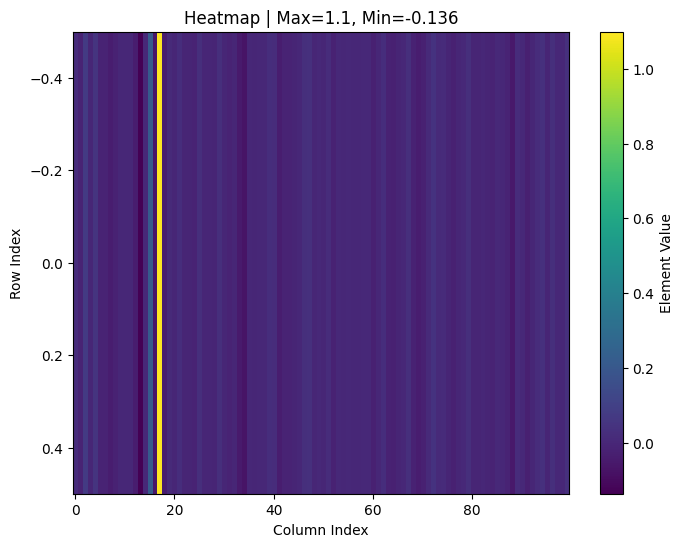

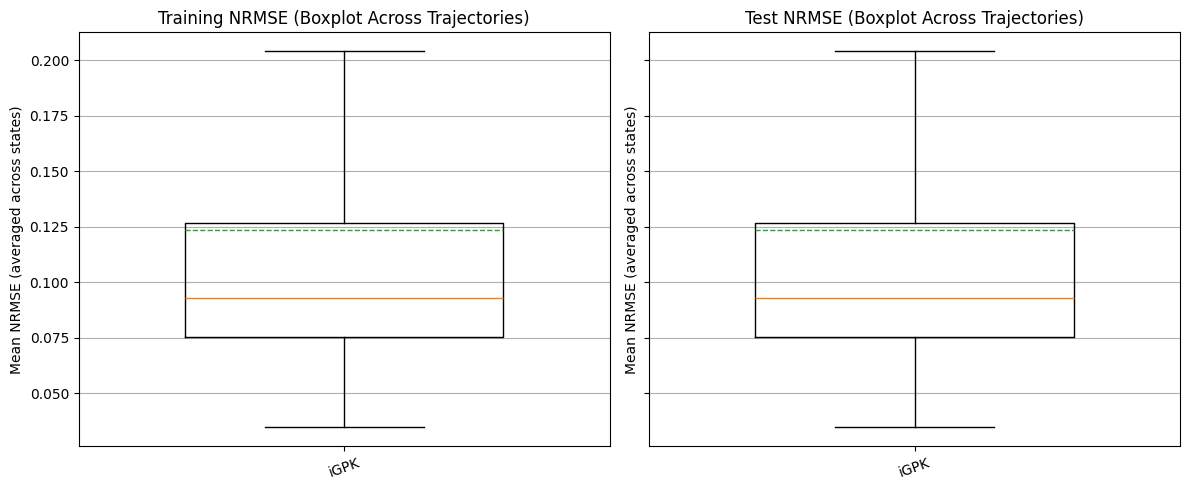

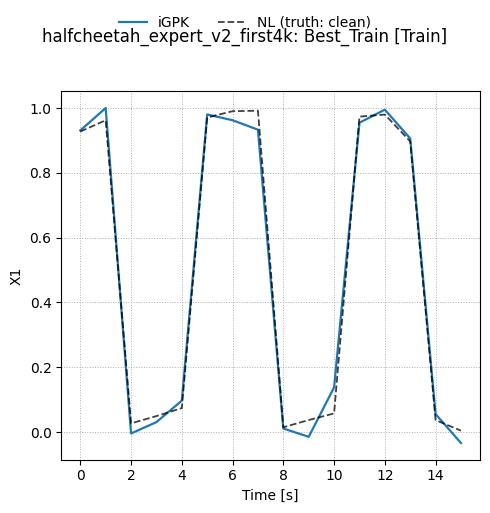

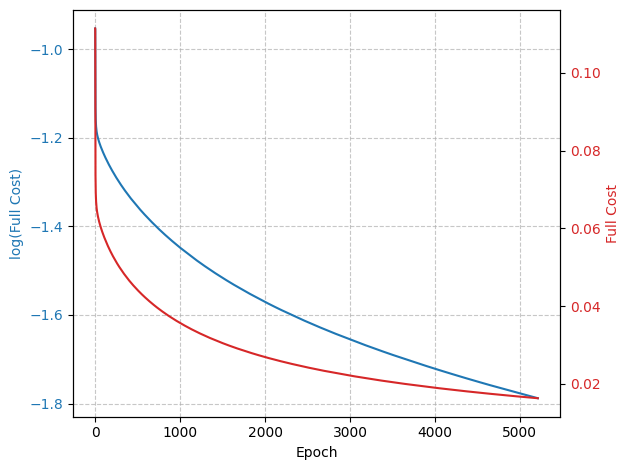

In [ ]:
if True:    # All Post-Processing and Outputs
    # unpack iGPK
    # ObsManager = results["ObsManager"]
    A_igpk, C_igpk = results["A"], results["C"]
    XhatTrain, TrainNRMSE = results["Train"]["Xhat"], results["Train"]["NRMSE"]
    # XhatTest,  XcvhatTest,  TestNRMSE = results["Test"][
    #     "Xhat"],  results["Test"]["Xcv"],  results["Test"]["NRMSE"]
    t_iGPK, total_epochs = results['history']['opt_time'], results[
        "history"]['iters']
    
    print(f'Lifted Model Order:         {LIFTING_ORDER:d}')
    print(f'Total Iterations executed:      {total_epochs:d}')
    print(f'Learning Time:              {t_iGPK:.2f} seconds')
    
    if A_igpk.shape[0] <= 50:
        gpk.plot_eigen(A_igpk)
    gpk.MatViz(C_igpk, 'heat')
    gpk.plot_NRMSE_metrics([TrainNRMSE*1], [TrainNRMSE*1], ['iGPK'])

    # 6) indices + timebase
    idx_trainMIN = torch.argmin(TrainNRMSE.mean(dim=1))
    # idx_testMIN = torch.argmin(TestNRMSE.mean(dim=1))
    # idx_testMAX = torch.argmax(TestNRMSE.mean(dim=1))
    time_arr = torch.arange(0., ts * (SimData.shape[2] - 1), ts)
    # print(f'Mean Test RMSE:         {1*float(TestNRMSE.mean()):.4f}')
    print(f'Mean Train RMSE:        {1*float(TrainNRMSE.mean()):.4f}')

    # 7) pack models for overlay plot
    models = [
        {"name": "iGPK",
         "train": {"Xhat": XhatTrain},
        # "test": {"Xhat": XhatTest, "Xcvhat": XcvhatTest},
            }
    ]

    # a) 3 trajectory overlays
    for (which, idx, split, sim_offset, suffix) in [
        ("best-train", idx_trainMIN, "train", nTest,         "Best_Train"),
    ]:
        gpk.compare_model_predictions(
            time=time_arr, models=models, SimData=SimData[:, 17:18, :], idx=idx, N=(
                SimData.shape[2]-1),
            system_name=SYSTEM_NAME, title_suffix=suffix, split=split, sim_offset=sim_offset,
            compare_to="SimData_clean", SimData_clean=SimData[:, 17:18, :], sigma=1.0
        )

    cost_history = results["history"].get("full_cost", None)
    # Plot Cost History
    fig, ax1 = plt.subplots()
    color = 'tab:blue'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('log(Full Cost)', color=color)
    ax1.plot(torch.log10(torch.abs(cost_history)), color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Full Cost', color=color)
    ax2.plot(cost_history, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    fig.tight_layout()

    # GT_test = SimData[:nTest, 17:18, :N-1]  # (nTest, n, N)

    # nlpd_traj_test_igpk = gpk.nlpd_per_traj(
    #     XhatTest[:, :, :N-1], XcvhatTest[:, :, :, :N-1], GT_test).detach().cpu()

    # print(f"Mean Test NLPD:     {nlpd_traj_test_igpk.mean():.4f}")

    plt.show()


## Baseline Models

In [ ]:
def eDMD_poly(SimData, nTrain, nTest, poly_deg=1):

    SimData = SimData.float()
    n, N = SimData.shape[1], SimData.shape[2] - 1

    X = torch.cat([SimData[nTest+j, :, 0:N] for j in range(nTrain)],
                  dim=1)       # Concatenated Data matrix
    # Time-shifted Data matrix
    Xplus = torch.cat([SimData[nTest+j, :, 1:] for j in range(nTrain)], dim=1)
    ICsetTrain = torch.cat([SimData[nTest+j, :, 0].view(n, 1)
                           for j in range(nTrain)], dim=1)
    ICsetTest = torch.cat([SimData[j, :, 0].view(n, 1)
                          for j in range(nTest)], dim=1)

    # Generate Polynomial Basis Function
    def phi_batch(X): return gpk.generate_basis_batch(X, poly_deg)

    # Lift state with generated polynomial basis functions
    phi_x = phi_batch(X)
    phi_xplus = phi_batch(Xplus)
    phi_x = phi_x[:100, :]
    phi_xplus = phi_xplus[:100, :]

    # Compute eDMD matrices
    A_edmd = phi_xplus @ torch.linalg.pinv(phi_x)
    C_edmd = X[17:18, :] @ torch.linalg.pinv(phi_x)
    p = C_edmd.shape[1]
    ny = C_edmd.shape[0]

    # ---------- Training ----------
    ZedTrain = torch.zeros((nTrain, p, N))
    XedTrain = torch.zeros((nTrain, ny, N))
    TrainNRMSE_eDMD = torch.zeros((nTrain, ny))

    for j in range(nTrain):
        # print(f'phi batch ic shape: {phi_batch(ICsetTrain[:, j].view(n, 1)).shape}')
        ZedTrain[j, :, 0] = phi_batch(ICsetTrain[:, j].view(n, 1))[:100, :].view(p,)
        ZedTrain[j, :, :], XedTrain[j, :, :] = gpk.sim_LTI(
            ZedTrain[j, :, 0], A_edmd, C_edmd, num_steps=N, ts=None, x0cv=None
        )

        true_vals = SimData[nTest+j, 17:18, :N]
        errors = XedTrain[j] - true_vals
        rmse = torch.sqrt(torch.mean(errors**2, dim=1))

        # range_vals = true_vals.max(dim=1).values - true_vals.min(dim=1).values
        # range_vals = torch.where(
        #     range_vals == 0, torch.ones_like(range_vals), range_vals)

        TrainNRMSE_eDMD[j] = rmse #/ range_vals

    # ---------- Testing ----------
    ZedTest = torch.zeros((nTest, p, N))
    XedTest = torch.zeros((nTest, ny, N))
    TestNRMSE_eDMD = torch.zeros((nTest, ny))

    for j in range(nTest):
        ZedTest[j, :, 0] = phi_batch(ICsetTest[:, j].view(n, 1))[:100, :].view(p,)
        ZedTest[j, :, :], XedTest[j, :, :] = gpk.sim_LTI(
            ZedTest[j, :, 0], A_edmd, C_edmd, num_steps=N, ts=None, x0cv=None
        )

        true_vals = SimData[j, 17:18, :N]
        errors = XedTest[j] - true_vals
        rmse = torch.sqrt(torch.mean(errors**2, dim=1))

        range_vals = true_vals.max(dim=1).values - true_vals.min(dim=1).values
        range_vals = torch.where(
            range_vals == 0, torch.ones_like(range_vals), range_vals)

        TestNRMSE_eDMD[j] = rmse #/ range_vals

    XedTrain, XedTest = XedTrain.detach(), XedTest.detach()
    TestNRMSE_eDMD, TrainNRMSE_eDMD = TestNRMSE_eDMD.detach(), TrainNRMSE_eDMD.detach()

    return A_edmd, C_edmd, XedTrain, XedTest, TrainNRMSE_eDMD, TestNRMSE_eDMD


def eDMD_RBF_kmeans(SimData, nTrain, nTest, num_centers, width=None, rbf_type='gaussian', state_aug=False):
    """
    Extended Dynamic Mode Decomposition (eDMD) using RBF observables defined via rbf_observable.

    Args:
        SimData (torch.Tensor): Simulation data of shape (num_trajectories, state_dim, num_time_steps).
        nTrain (int): Number of trajectories used for training.
        nTest (int): Number of trajectories used for testing.
        centers (torch.Tensor): RBF centers of shape (state_dim, m) where m is the number of RBFs.
        width (float or torch.Tensor, optional): For Gaussian RBF, either a scalar or a 1D tensor of length m.
            Ignored for thin-plate spline RBF.
        rbf_type (str): Type of RBF to use: 'gaussian' or 'thin_plate'.

    Returns:
        A_edmd (torch.Tensor): The estimated system matrix in the lifted space.
        C_edmd (torch.Tensor): The reconstruction matrix from the lifted space to the state space.
        XedTrain (torch.Tensor): Predicted training trajectories.
        XedTest (torch.Tensor): Predicted testing trajectories.
        TrainNRMSE_eDMD (torch.Tensor): NRMSE for each state in each training trajectory.
        TestNRMSE_eDMD (torch.Tensor): NRMSE for each state in each testing trajectory.
    """
    SimData = SimData.float()
    n, N = SimData.shape[1], SimData.shape[2] - 1

    # Concatenate data for training: X and its time-shifted version Xplus.
    X = torch.cat([SimData[nTest+j, :, 0:N] for j in range(nTrain)], dim=1)
    Xplus = torch.cat([SimData[nTest+j, :, 1:] for j in range(nTrain)], dim=1)
    # Initial conditions for training and testing.
    ICsetTrain = torch.cat([SimData[nTest+j, :, 0].view(n, 1)
                           for j in range(nTrain)], dim=1)
    ICsetTest = torch.cat([SimData[j, :, 0].view(n, 1)
                          for j in range(nTest)], dim=1)

    centers = gpk.get_kmeans(X, num_centers)

    # Lift the data.
    # shape: (m, total training samples)
    phi_x = gpk.rbf_observable(X, centers, width, rbf_type, state_aug)
    phi_xplus = gpk.rbf_observable(Xplus, centers, width, rbf_type, state_aug)

    # Compute the eDMD matrices using a pseudo-inverse.
    A_edmd = phi_xplus @ torch.linalg.pinv(phi_x)
    p = A_edmd.shape[0]  # p is the number of lifted observables (typically m).
    if state_aug:
        C_edmd = torch.zeros((n, p))
        for i in range(n):
            C_edmd[i, i] = 1.
    else:
        C_edmd = X[17:18, :] @ torch.linalg.pinv(phi_x)

    ny = C_edmd.shape[0]
    
    # Evaluate on the training set.
    ZedTrain = torch.zeros((nTrain, p, N))
    XedTrain = torch.zeros((nTrain, ny, N))
    TrainNRMSE_eDMD = torch.zeros((nTrain, ny))

    for j in range(nTrain):
        # Lift the initial condition for the j-th training trajectory.
        ZedTrain[j, :, 0] = gpk.rbf_observable(ICsetTrain[:, j].view(
            n, 1), centers, width, rbf_type, state_aug).view(p,)
        # Simulate the lifted linear system.
        ZedTrain[j, :, :], XedTrain[j, :, :] = gpk.sim_LTI(ZedTrain[j, :, 0], A_edmd, C_edmd,
                                                       num_steps=N, ts=None, x0cv=None)
        true_vals = SimData[nTest+j, 17:18, :N]
        errors = XedTrain[j, :, :] - true_vals
        rmse = torch.sqrt(torch.mean(errors**2, dim=1))
        range_vals = torch.max(true_vals, dim=1).values - torch.min(true_vals, dim=1).values
        range_vals = torch.where(range_vals == 0, torch.ones_like(range_vals), range_vals)
        TrainNRMSE_eDMD[j, :] = rmse #/ range_vals

    # Evaluate on the test set.
    ZedTest = torch.zeros((nTest, p, N))
    XedTest = torch.zeros((nTest, ny, N))
    TestNRMSE_eDMD = torch.zeros((nTest, ny))

    for j in range(nTest):
        ZedTest[j, :, 0] = gpk.rbf_observable(ICsetTest[:, j].view(
            n, 1), centers, width, rbf_type, state_aug).view(p,)
        ZedTest[j, :, :], XedTest[j, :, :] = gpk.sim_LTI(ZedTest[j, :, 0], A_edmd, C_edmd,
                                                     num_steps=N, ts=None, x0cv=None)
        true_vals = SimData[j, 17:18, :N]
        errors = XedTest[j, :, :] - true_vals
        rmse = torch.sqrt(torch.mean(errors**2, dim=1))
        range_vals = torch.max(true_vals, dim=1).values - torch.min(true_vals, dim=1).values
        range_vals = torch.where(range_vals == 0, torch.ones_like(range_vals), range_vals)
        TestNRMSE_eDMD[j, :] = rmse #/ range_vals

    # Detach results.
    XedTrain, XedTest = XedTrain.detach(), XedTest.detach()
    TrainNRMSE_eDMD, TestNRMSE_eDMD = TrainNRMSE_eDMD.detach(), TestNRMSE_eDMD.detach()

    return A_edmd, C_edmd, XedTrain, XedTest, TrainNRMSE_eDMD, TestNRMSE_eDMD

def get_ssidgpk(SimData: torch.tensor, nTrain: int, nTest: int, lifting_order: int, delay: int):

    # Data Preparation
    n, N = SimData.shape[1], SimData.shape[2]
    ssid_Y = SimData[nTest:nTest+nTrain, :, :]
    ssid_U = torch.zeros(
        (nTrain, 1, N), dtype=ssid_Y.dtype, device=ssid_Y.device)
    ICsetTrain = torch.cat([SimData[nTest+j, :, 0].view(n, 1)
                           for j in range(nTrain)], dim=1)
    ICsetTest = torch.cat([SimData[j, :, 0].view(n, 1)
                          for j in range(nTest)], dim=1)

    # Multi-Trajectory Subspace Identification
    A, B, C, D, z0_lift = gpk.SSID(
        ssid_U, ssid_Y, delay=delay, sys_dim=lifting_order)
    C = C[17:18, :]

    # Gaussian Process Regression
    ObsManager = gpk.GPObservablesManager()
    for i in range(lifting_order):
        ObsManager.add_observable(
            index=i, d=ssid_Y.shape[1], Ns=z0_lift.shape[1], 
            kernel=gpk.GaussianKernel(), noise=1e-4, device='cpu',
        )
    ObsManager.set_random_hyperparameters(scale=[1., 1., None])
    for i in range(lifting_order):
        ObsManager.train_observable(i, ssid_Y[:, :, 0].mT, z0_lift[i, :].unsqueeze(dim=1))

    ObsManager.optimize_hyperparameters(num_iter=100, lr=0.01, opt_noise=True)

    # Trajectory Simulation and Model Evaluation
    XhatTrain, TrainNRMSE = sim_and_eval(
        ObsManager, A, C, ICsetTrain, SimData, traj_offset=nTest)
    XhatTest, TestNRMSE = sim_and_eval(
        ObsManager, A, C, ICsetTest,  SimData, traj_offset=0)

    return {
        "ObsManager": ObsManager,
        "A": A, "B": B, "C": C, "D": D,
        "ICsetTrain": ICsetTrain.detach().cpu(),
        "ICsetTest":  ICsetTest.detach().cpu(),
        "Train": {
            "Xhat": XhatTrain,           # (nTrain, n, N)
            "Xcv":  None,            # (nTrain, n, n, N)
            "NRMSE": TrainNRMSE          # (nTrain, n)
        },
        "Test": {
            "Xhat": XhatTest,            # (nTest, n, N)
            "Xcv":  None,             # (nTest, n, n, N)
            "NRMSE": TestNRMSE           # (nTest, n)
        }
    }


In [12]:
if True:    # Baselines
    # 4) eDMDs
    t0 = time.perf_counter()
    _, _, XhatTrain_poly, XhatTest_poly, TrainNRMSE_poly, TestNRMSE_poly = eDMD_poly(
        SimData, nTrain, nTest, poly_deg=2)
    t_poly = time.perf_counter() - t0
    print(f'Poly-eDMD output shape: {XhatTrain_poly.shape}')

    # t0 = time.perf_counter()
    # _, _, XhatTrain_rbf, XhatTest_rbf, TrainNRMSE_rbf, TestNRMSE_rbf = eDMD_RBF_kmeans(
    #     SimData, nTrain, nTest, num_centers=LIFTING_ORDER, width=HP_INIT,
    #     rbf_type='gaussian', state_aug=False)
    # t_rbf = time.perf_counter() - t0
    # print(f'RBF-eDMD output shape: {XhatTrain_rbf.shape}')

    # # 5) SSID-GPK
    # t0 = time.perf_counter()
    # results_ssid = get_ssidgpk(
    #     SimData=SimData,
    #     nTrain=nTrain, nTest=nTest,
    #     lifting_order=LIFTING_ORDER,
    #     delay=4)
    # t_ssid = time.perf_counter() - t0
    # print(f'SSID-GPK output shape: {results_ssid["Train"]["Xhat"].shape}')

    # unpack SSID-GPK results
    # A_ssid, C_ssid = results_ssid["A"], results_ssid["C"]
    # ObsManager_ssid = results_ssid["ObsManager"]
    
    # XhatTest_ssid,  XcvhatTest_ssid,  TestNRMSE_ssid = results_ssid["Test"][
    #     "Xhat"],  results_ssid["Test"]["Xcv"],  results_ssid["Test"]["NRMSE"]

Poly-eDMD output shape: torch.Size([3000, 1, 16])


In [13]:
print(f'============ Summary of Results ============')
try:    # Baseline Plots
    print('============================================')
    print(f'Polynomial eDMD with degree 2 took {t_poly:.2f} seconds.')
    print(f'Mean Test RMSE:         {1*float(TestNRMSE_poly.mean()):.4f}')
    print(f'Mean Train RMSE:        {1*float(TrainNRMSE_poly.mean()):.4f}')
except NameError:
    pass

try:
    print('============================================')
    print(f'RBF eDMD with degree 2 took {t_rbf:.2f} seconds.')
    print(f'Mean Test RMSE:         {1*float(TestNRMSE_rbf.mean()):.4f}')
    print(f'Mean Train RMSE:        {1*float(TrainNRMSE_rbf.mean()):.4f}')
except NameError:
    pass

try:
    print('============================================')
    TrainNRMSE_ssid = results_ssid["Train"]["NRMSE"]
    print(f'SSID-GPK with degree 2 took {t_ssid:.2f} seconds.')
    # print(f'Mean Test RMSE:         {1*float(TestNRMSE_ssid.mean()):.4f}')
    print(f'Mean Train RMSE:        {1*float(TrainNRMSE_ssid.mean()):.4f}')
    print('============================================')
except NameError:
    pass

============ Summary of Results ============
Polynomial eDMD with degree 2 took 221.98 seconds.
Mean Test RMSE:         0.1375
Mean Train RMSE:        0.1184


#### Optional Plotting

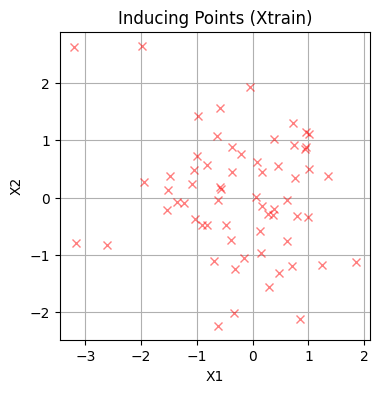

In [ ]:
# Plot the Xtrain points in 2D space
Xtrain = Dataset['Xtrain']
if Xtrain.shape[0] >= 2:    # Optional Plotting in 2D space
    Xtrain_plot = Xtrain.cpu()
    plt.figure(figsize=(4,4))
    for i in range(Xtrain.shape[1]):
        plt.plot(Xtrain_plot[0,i], Xtrain_plot[1,i], linestyle='None', marker='x', color='red', alpha=0.5)
    plt.xlabel('X1'), plt.ylabel('X2'), plt.grid()
    plt.title('Inducing Points (Xtrain)')
    plt.show()